# Monte Carlo Control no Blackjack

Este notebook implementa, de forma independente, o experimento de **Monte Carlo Control on-policy com política ε-greedy** no ambiente `Blackjack-v1`, tomando como base a implementação disponibilizada na disciplina.

Nesta etapa, o objetivo deixa de ser apenas estimar \(V^\pi(s)\). O algoritmo passa a aprender uma função de valor de ação \(Q(s,a)\) e, a partir dela, melhorar progressivamente a política.

Serão realizados dois experimentos controlados:

1. **Efeito do número de episódios**, mantendo `epsilon = 0.1`;
2. **Efeito da exploração**, variando `epsilon` e mantendo fixo o número de episódios.


## 1. Introdução

No Monte Carlo Control, o agente aprende diretamente a partir de episódios completos.

A política utilizada durante o aprendizado é ε-greedy:

- com maior probabilidade, escolhe a ação atualmente considerada melhor;
- com probabilidade controlada por \(\epsilon\), escolhe ações de exploração.

O objetivo é investigar:

- como a quantidade de episódios afeta a estabilidade e o desempenho da política aprendida;
- como diferentes valores de \(\epsilon\) alteram o equilíbrio entre exploração e aproveitamento.


### Hipóteses

Espera-se que:

- mais episódios produzam estimativas de \(Q(s,a)\) mais estáveis;
- valores muito baixos de \(\epsilon\) possam reduzir exploração e atrasar a descoberta de ações melhores;
- valores mais altos de \(\epsilon\) aumentem a exploração, mas mantenham maior aleatoriedade durante o aprendizado;
- um valor intermediário, como `epsilon = 0.1`, apresente bom equilíbrio entre exploração e aproveitamento.


## 2. Fundamentação teórica

### 2.1 Monte Carlo Control

Monte Carlo Control estima valores de ação:

$$
Q(s,a)
$$

a partir dos retornos observados após visitas a pares estado-ação.

No método First Visit, para cada episódio utiliza-se apenas a primeira ocorrência de cada par \((s,a)\).

A estimativa é atualizada pela média dos retornos observados:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\frac{1}{N(s,a)}
\left(
G_t - Q(s,a)
\right)
$$


### 2.2 Política ε-greedy

Para \(m\) ações possíveis:

$$
\pi(a \mid s) =
\begin{cases}
\frac{\epsilon}{m} + 1 - \epsilon,
& \text{se } a = \arg\max_{a \in \mathcal{A}} Q(s,a) \\
\frac{\epsilon}{m},
& \text{caso contrário}
\end{cases}
$$

No Blackjack existem duas ações:

- `0 = stick`
- `1 = hit`

A política permanece exploratória durante todo o treinamento quando \(\epsilon > 0\).


## 3. Ambiente Blackjack-v1

O estado é representado por:

$$
(\text{soma do jogador},\ \text{carta visível do dealer},\ \text{ás utilizável})
$$

Recompensas:

- vitória: `+1`
- empate: `0`
- derrota: `-1`

Configuração utilizada:

- `natural=False`
- `sab=False`


## 4. Configuração experimental


In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from collections import defaultdict

%matplotlib inline
matplotlib.style.use("ggplot")


### 4.1 Seeds e parâmetros gerais

Cada configuração será repetida com cinco seeds independentes.

A seed é definida uma vez no início de cada repetição, permitindo episódios diferentes dentro da mesma execução, mas mantendo reprodutibilidade global.


In [2]:
BASE_SEED = 42
N_RUNS = 5
SEEDS = [BASE_SEED + i for i in range(N_RUNS)]

GAMMA = 1.0

print("Seeds:", SEEDS)


Seeds: [42, 43, 44, 45, 46]


### 4.2 Experimento A — efeito do número de episódios

Mantém-se:

```python
epsilon = 0.1
```

e varia-se:

- 10.000 episódios
- 100.000 episódios
- 500.000 episódios


In [3]:
CONTROL_EPISODES = [
    10_000,
    100_000,
    500_000,
]

FIXED_EPSILON = 0.1


### 4.3 Experimento B — efeito de epsilon

Mantém-se:

```python
num_episodes = 100_000
```

e varia-se:

- `epsilon = 0.01`
- `epsilon = 0.10`
- `epsilon = 0.20`


In [4]:
EPSILONS = [
    0.01,
    0.10,
    0.20,
]

FIXED_CONTROL_EPISODES = 100_000


## 5. Criação do ambiente


In [5]:
def make_env():
    return gym.make(
        "Blackjack-v1",
        natural=False,
        sab=False
    )


## 6. Política ε-greedy

A função retorna a distribuição de probabilidade das ações para um estado.

Como existem duas ações, uma parte de \(\epsilon\) é distribuída igualmente entre ambas, enquanto a ação de maior valor recebe adicionalmente \(1-\epsilon\).


In [6]:
def make_epsilon_greedy_policy(Q, epsilon, n_actions):
    def policy_fn(observation):
        probabilities = np.ones(
            n_actions,
            dtype=float
        ) * (epsilon / n_actions)

        best_action = np.argmax(
            Q[observation]
        )

        probabilities[best_action] += (
            1.0 - epsilon
        )

        return probabilities

    return policy_fn


## 7. Geração de episódios

Durante o treinamento, as ações são sorteadas de acordo com a política ε-greedy.

É utilizado um gerador NumPy explícito para garantir reprodutibilidade da sequência de ações exploratórias.


In [7]:
def generate_episode(env, policy, rng):
    episode = []

    observation, info = env.reset()

    while True:
        probabilities = policy(observation)

        action = rng.choice(
            np.arange(len(probabilities)),
            p=probabilities
        )

        next_observation, reward, terminated, truncated, info = env.step(action)

        episode.append(
            (observation, action, reward)
        )

        observation = next_observation

        if terminated or truncated:
            break

    return episode


## 8. Monte Carlo Control — First Visit

Para cada episódio:

1. gera-se uma trajetória com a política ε-greedy atual;
2. identificam-se os pares \((s,a)\) visitados;
3. apenas a primeira ocorrência de cada par é usada;
4. calcula-se o retorno \(G_t\);
5. atualiza-se \(Q(s,a)\);
6. como a política consulta diretamente \(Q\), sua preferência muda automaticamente conforme os valores são atualizados.


In [8]:
def mc_control_epsilon_greedy(
    env,
    num_episodes,
    gamma=1.0,
    epsilon=0.1,
    seed=42
):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    Q = defaultdict(
        lambda: np.zeros(
            env.action_space.n,
            dtype=float
        )
    )

    visit_counts = defaultdict(int)

    policy = make_epsilon_greedy_policy(
        Q,
        epsilon,
        env.action_space.n
    )

    rng = np.random.default_rng(seed)

    for _ in range(num_episodes):
        episode = generate_episode(
            env,
            policy,
            rng
        )

        visited_state_actions = set()

        for t, (state, action, reward) in enumerate(episode):
            state = tuple(state)
            state_action = (
                state,
                int(action)
            )

            if state_action in visited_state_actions:
                continue

            visited_state_actions.add(
                state_action
            )

            G = 0.0

            for k, (_, _, reward_k) in enumerate(episode[t:]):
                G += (
                    gamma ** k
                ) * reward_k

            returns_sum[state_action] += G
            returns_count[state_action] += 1
            visit_counts[state_action] += 1

            Q[state][action] = (
                returns_sum[state_action]
                / returns_count[state_action]
            )

    return Q, policy, visit_counts


## 9. Avaliação gulosa da política aprendida

Durante o treinamento, a política continua ε-greedy.

Para avaliar a qualidade da solução aprendida sem o ruído da exploração, utiliza-se uma política **gulosa** derivada de \(Q\):

```python
argmax_a Q(s,a)
```

Assim, a avaliação mede a política final aprendida, e não a aleatoriedade introduzida por ε.


In [9]:
def greedy_action(Q, state):
    return int(
        np.argmax(Q[state])
    )


def evaluate_greedy_policy(
    Q,
    episodes=10_000,
    seed=10_000
):
    env = make_env()
    env.reset(seed=seed)

    rewards = []
    steps_per_episode = []

    for _ in range(episodes):
        state, info = env.reset()

        terminated = False
        truncated = False

        total_reward = 0.0
        steps = 0

        while not (
            terminated or truncated
        ):
            action = greedy_action(
                Q,
                tuple(state)
            )

            state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            steps += 1

        rewards.append(
            total_reward
        )

        steps_per_episode.append(
            steps
        )

    env.close()

    rewards = np.asarray(rewards)

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "win_rate": np.mean(rewards == 1),
        "draw_rate": np.mean(rewards == 0),
        "loss_rate": np.mean(rewards == -1),
        "mean_steps": np.mean(steps_per_episode),
    }


## 10. Experimento A — número de episódios

Cada quantidade de episódios é executada com as mesmas cinco seeds.

Após cada treinamento, a política gulosa derivada de \(Q\) é avaliada em 10.000 novos episódios.


In [10]:
episode_results = []

for num_episodes in CONTROL_EPISODES:

    for seed in SEEDS:
        env = make_env()
        env.reset(seed=seed)

        Q, policy, visit_counts = mc_control_epsilon_greedy(
            env,
            num_episodes=num_episodes,
            gamma=GAMMA,
            epsilon=FIXED_EPSILON,
            seed=seed
        )

        env.close()

        evaluation = evaluate_greedy_policy(
            Q,
            episodes=10_000,
            seed=100_000 + seed
        )

        episode_results.append({
            "episodes": num_episodes,
            "epsilon": FIXED_EPSILON,
            "seed": seed,
            "Q": Q,
            "visit_counts": visit_counts,
            "evaluation": evaluation,
        })

    print(
        f"{num_episodes:,} episódios concluídos"
    )


10,000 episódios concluídos
100,000 episódios concluídos
500,000 episódios concluídos


### 10.1 Tabela-resumo do Experimento A


In [18]:
episode_summary_rows = []

for num_episodes in CONTROL_EPISODES:
    subset = [
        result
        for result in episode_results
        if result["episodes"] == num_episodes
    ]

    episode_summary_rows.append({
        "Episódios": num_episodes,
        "Recompensa média": np.mean([
            r["evaluation"]["mean_reward"]
            for r in subset
        ]),
        "DP recompensa": np.std([
            r["evaluation"]["mean_reward"]
            for r in subset
        ]),
        "Taxa de vitória": np.mean([
            r["evaluation"]["win_rate"]
            for r in subset
        ]),
        "Taxa de empate": np.mean([
            r["evaluation"]["draw_rate"]
            for r in subset
        ]),
        "Taxa de derrota": np.mean([
            r["evaluation"]["loss_rate"]
            for r in subset
        ]),
        "Passos médios": np.mean([
            r["evaluation"]["mean_steps"]
            for r in subset
        ]),
    })

episode_summary_df = pd.DataFrame(
    episode_summary_rows
)

episode_summary_df


,Episódios,Recompensa média,DP recompensa,Taxa de vitória,Taxa de empate,Taxa de derrota,Passos médios
0,10000,-0.12150,0.010043,0.40138,0.07574,0.52288,1.30998
1,100000,-0.06726,0.005547,0.42232,0.08810,0.48958,1.45894
2,500000,-0.04672,0.010720,0.43048,0.09232,0.47720,1.51184


### 10.2 Desempenho em função do número de episódios


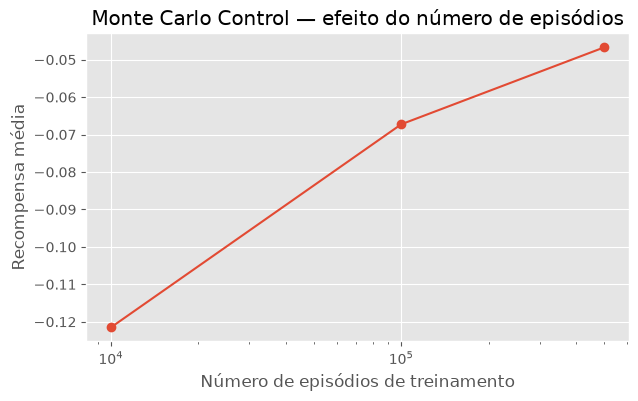

In [19]:
plt.figure(figsize=(7, 4))

plt.plot(
    episode_summary_df["Episódios"],
    episode_summary_df["Recompensa média"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Número de episódios de treinamento")
plt.ylabel("Recompensa média")
plt.title(
    "Monte Carlo Control — efeito do número de episódios"
)

plt.grid(True)
plt.show()


### 10.3 Cobertura dos pares estado-ação

Para avaliar a qualidade da exploração, registra-se a frequência de visitas aos pares \((s,a)\).

Quanto maior a cobertura, maior a quantidade de pares estado-ação que receberam estimativas baseadas em amostras reais.

In [20]:
coverage_episode_rows = []

for num_episodes in CONTROL_EPISODES:

    subset = [
        result
        for result in episode_results
        if result["episodes"] == num_episodes
    ]

    visited_pairs = []
    total_visits = []

    for result in subset:
        counts = result["visit_counts"]

        visited_pairs.append(
            sum(
                1
                for count in counts.values()
                if count > 0
            )
        )

        total_visits.append(
            sum(counts.values())
        )

    coverage_episode_rows.append({
        "Episódios": num_episodes,
        "Pares (s,a) visitados - média": np.mean(visited_pairs),
        "Pares (s,a) visitados - DP": np.std(visited_pairs),
        "Visitas totais - média": np.mean(total_visits),
    })

coverage_episode_df = pd.DataFrame(
    coverage_episode_rows
)

coverage_episode_df

,Episódios,"Pares (s,a) visitados - média","Pares (s,a) visitados - DP",Visitas totais - média
0,10000,535.0,1.788854,12515.6
1,100000,560.0,0.000000,139844.6
2,500000,560.0,0.000000,733138.6


## 11. Experimento B — efeito de epsilon

Agora o número de episódios é fixado em 100.000 e varia-se o nível de exploração.


In [13]:
epsilon_results = []

for epsilon in EPSILONS:

    for seed in SEEDS:
        env = make_env()
        env.reset(seed=seed)

        Q, policy, visit_counts = mc_control_epsilon_greedy(
            env,
            num_episodes=FIXED_CONTROL_EPISODES,
            gamma=GAMMA,
            epsilon=epsilon,
            seed=seed
        )

        env.close()

        evaluation = evaluate_greedy_policy(
            Q,
            episodes=10_000,
            seed=200_000 + seed
        )

        epsilon_results.append({
            "episodes": FIXED_CONTROL_EPISODES,
            "epsilon": epsilon,
            "seed": seed,
            "Q": Q,
            "visit_counts": visit_counts,
            "evaluation": evaluation,
        })

    print(
        f"epsilon={epsilon:.2f} concluído"
    )


epsilon=0.01 concluído
epsilon=0.10 concluído
epsilon=0.20 concluído


### 11.1 Tabela-resumo do Experimento B


In [14]:
epsilon_summary_rows = []

for epsilon in EPSILONS:
    subset = [
        result
        for result in epsilon_results
        if np.isclose(
            result["epsilon"],
            epsilon
        )
    ]

    epsilon_summary_rows.append({
        "Epsilon": epsilon,
        "Recompensa média": np.mean([
            r["evaluation"]["mean_reward"]
            for r in subset
        ]),
        "DP recompensa": np.std([
            r["evaluation"]["mean_reward"]
            for r in subset
        ]),
        "Taxa de vitória": np.mean([
            r["evaluation"]["win_rate"]
            for r in subset
        ]),
        "Taxa de empate": np.mean([
            r["evaluation"]["draw_rate"]
            for r in subset
        ]),
        "Taxa de derrota": np.mean([
            r["evaluation"]["loss_rate"]
            for r in subset
        ]),
        "Passos médios": np.mean([
            r["evaluation"]["mean_steps"]
            for r in subset
        ]),
    })

epsilon_summary_df = pd.DataFrame(
    epsilon_summary_rows
)

epsilon_summary_df


,Epsilon,Recompensa média,DP recompensa,Taxa de vitória,Taxa de empate,Taxa de derrota,Passos médios
0,0.01,-0.10838,0.016784,0.40922,0.07318,0.51760,1.30298
1,0.10,-0.06266,0.003480,0.42506,0.08722,0.48772,1.45314
2,0.20,-0.05354,0.010558,0.42960,0.08726,0.48314,1.45920


### 11.2 Desempenho em função de epsilon


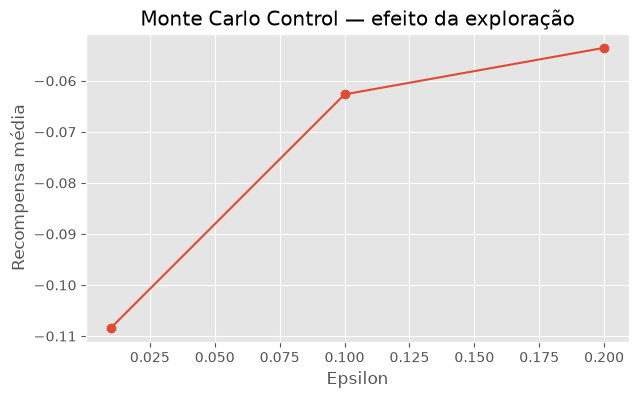

In [15]:
plt.figure(figsize=(7, 4))

plt.plot(
    epsilon_summary_df["Epsilon"],
    epsilon_summary_df["Recompensa média"],
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("Recompensa média")
plt.title(
    "Monte Carlo Control — efeito da exploração"
)

plt.grid(True)
plt.show()


### 11.3 Cobertura em função de epsilon

Esta análise verifica se valores maiores de $\epsilon$ aumentam a exploração efetiva do espaço estado-ação.

In [21]:
coverage_epsilon_rows = []

for epsilon in EPSILONS:

    subset = [
        result
        for result in epsilon_results
        if np.isclose(
            result["epsilon"],
            epsilon
        )
    ]

    visited_pairs = []
    total_visits = []

    for result in subset:
        counts = result["visit_counts"]

        visited_pairs.append(
            sum(
                1
                for count in counts.values()
                if count > 0
            )
        )

        total_visits.append(
            sum(counts.values())
        )

    coverage_epsilon_rows.append({
        "Epsilon": epsilon,
        "Pares (s,a) visitados - média": np.mean(visited_pairs),
        "Pares (s,a) visitados - DP": np.std(visited_pairs),
        "Visitas totais - média": np.mean(total_visits),
    })

coverage_epsilon_df = pd.DataFrame(
    coverage_epsilon_rows
)

coverage_epsilon_df

,Epsilon,"Pares (s,a) visitados - média","Pares (s,a) visitados - DP",Visitas totais - média
0,0.01,547.4,3.261901,126317.6
1,0.10,560.0,0.000000,139844.6
2,0.20,560.0,0.000000,139801.0


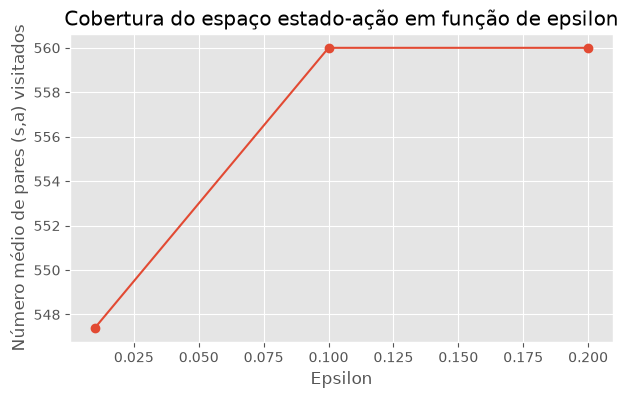

In [23]:
plt.figure(figsize=(7, 4))

plt.plot(
    coverage_epsilon_df["Epsilon"],
    coverage_epsilon_df["Pares (s,a) visitados - média"],
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("Número médio de pares (s,a) visitados")
plt.title(
    "Cobertura do espaço estado-ação em função de epsilon"
)

plt.grid(True)
plt.show()

## 12. Visualização da política aprendida

A política gulosa derivada de \(Q\) pode ser visualizada em duas matrizes:

- sem ás utilizável;
- com ás utilizável.

Em cada célula:

- `S` representa `stick`;
- `H` representa `hit`.


In [16]:
PLAYER_SUMS = np.arange(12, 22)
DEALER_CARDS = np.arange(1, 11)


def policy_matrix(Q, usable_ace):
    matrix = np.empty(
        (
            len(DEALER_CARDS),
            len(PLAYER_SUMS)
        ),
        dtype=object
    )

    for i, dealer in enumerate(DEALER_CARDS):
        for j, player_sum in enumerate(PLAYER_SUMS):
            state = (
                int(player_sum),
                int(dealer),
                bool(usable_ace)
            )

            action = greedy_action(
                Q,
                state
            )

            matrix[i, j] = (
                "S"
                if action == 0
                else "H"
            )

    return matrix


def plot_policy(Q, title):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    for ax, usable_ace, subtitle in [
        (axes[0], False, "Sem ás utilizável"),
        (axes[1], True, "Com ás utilizável"),
    ]:
        matrix = policy_matrix(
            Q,
            usable_ace
        )

        numeric = np.where(
            matrix == "H",
            1,
            0
        )

        ax.imshow(
            numeric,
            origin="lower",
            aspect="auto",
            cmap="coolwarm",
            vmin=0,
            vmax=1
        )

        for i in range(
            len(DEALER_CARDS)
        ):
            for j in range(
                len(PLAYER_SUMS)
            ):
                ax.text(
                    j,
                    i,
                    matrix[i, j],
                    ha="center",
                    va="center",
                    fontweight="bold"
                )

        ax.set_xticks(
            np.arange(
                len(PLAYER_SUMS)
            )
        )

        ax.set_xticklabels(
            PLAYER_SUMS
        )

        ax.set_yticks(
            np.arange(
                len(DEALER_CARDS)
            )
        )

        ax.set_yticklabels(
            DEALER_CARDS
        )

        ax.set_xlabel(
            "Soma do jogador"
        )

        ax.set_ylabel(
            "Carta visível do dealer"
        )

        ax.set_title(
            subtitle
        )

    fig.suptitle(title)
    plt.show()


### 12.1 Política de uma execução representativa

Para visualização, será utilizada a execução com:

- 500.000 episódios;
- `epsilon = 0.1`;
- `seed = 42`.


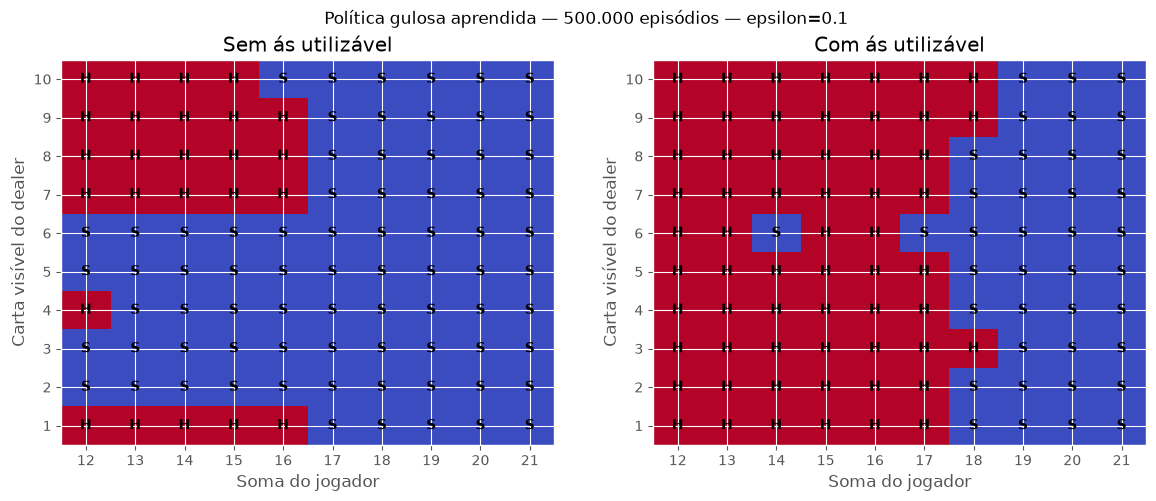

In [17]:
representative_result = next(
    result
    for result in episode_results
    if (
        result["episodes"] == 500_000
        and result["seed"] == 42
    )
)

plot_policy(
    representative_result["Q"],
    title=(
        "Política gulosa aprendida — "
        "500.000 episódios — epsilon=0.1"
    )
)


## 13. Monte Carlo Prediction da política aprendida

O Monte Carlo Control produziu uma função de valor de ação $Q(s,a)$ e, a partir dela, uma política gulosa:

$$
\pi_{\text{aprendida}}(s)
=
\arg\max_a Q(s,a)
$$

Nesta etapa, essa política deixa de ser modificada e passa a ser tratada como uma política fixa.

O objetivo é utilizar **Monte Carlo Prediction — First Visit** para estimar:

$$
V^{\pi_{\text{aprendida}}}(s)
$$

Isso permite responder a uma pergunta diferente daquela respondida pelo Control:

- **Control:** qual ação deve ser escolhida em cada estado?
- **Prediction:** qual é o retorno esperado ao partir de cada estado e seguir essa política?

Para reduzir a influência de uma única sequência aleatória, a avaliação será repetida com as mesmas cinco seeds utilizadas nos experimentos anteriores.

In [24]:
PREDICTION_EVAL_EPISODES = 100_000
PREDICTION_EVAL_SEEDS = SEEDS


# Política original utilizada no experimento de Prediction.
def fixed_policy(observation):
    player_sum, dealer_card, usable_ace = observation
    return 0 if player_sum >= 20 else 1


# Política gulosa obtida pelo Monte Carlo Control.
def learned_policy(observation):
    state = tuple(observation)

    return int(
        np.argmax(
            representative_result["Q"][state]
        )
    )

### 13.1 Geração de episódios para Prediction

Diferentemente do treinamento do Control, nesta etapa não existe exploração ε-greedy.

Cada política recebe um estado e retorna diretamente uma ação. Os episódios utilizados na avaliação são novos e não reutilizam os episódios empregados durante o treinamento.

In [25]:
def generate_prediction_episode(env, policy):
    episode = []

    observation, info = env.reset()

    while True:
        action = policy(observation)

        next_observation, reward, terminated, truncated, info = env.step(
            action
        )

        episode.append(
            (observation, action, reward)
        )

        observation = next_observation

        if terminated or truncated:
            break

    return episode

### 13.2 Monte Carlo Prediction — First Visit

A função abaixo estima $V^\pi(s)$ utilizando apenas a primeira visita a cada estado em um episódio.

In [26]:
def mc_prediction_first_visit(
    env,
    policy,
    num_episodes,
    gamma=1.0
):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    V = defaultdict(float)

    for _ in range(num_episodes):

        episode = generate_prediction_episode(
            env,
            policy
        )

        visited_states = set()

        for t, (state, action, reward) in enumerate(episode):

            state = tuple(state)

            if state in visited_states:
                continue

            visited_states.add(state)

            G = 0.0

            for k, (_, _, reward_k) in enumerate(
                episode[t:]
            ):
                G += (
                    gamma ** k
                ) * reward_k

            returns_sum[state] += G
            returns_count[state] += 1

            V[state] = (
                returns_sum[state]
                / returns_count[state]
            )

    return V, returns_count

### 13.3 Execução das avaliações

A política fixa original e a política aprendida são avaliadas com:

- 100.000 episódios por repetição;
- cinco seeds;
- $\gamma = 1$.

As duas políticas são avaliadas separadamente, sem exploração adicional.

In [27]:
prediction_comparison = {
    "Política fixa": [],
    "Política aprendida": [],
}

policies_to_evaluate = {
    "Política fixa": fixed_policy,
    "Política aprendida": learned_policy,
}


for policy_name, policy_fn in policies_to_evaluate.items():

    for seed in PREDICTION_EVAL_SEEDS:

        env = make_env()

        # Inicializa o RNG da repetição.
        env.reset(seed=seed)

        V, visit_counts = mc_prediction_first_visit(
            env,
            policy_fn,
            num_episodes=PREDICTION_EVAL_EPISODES,
            gamma=GAMMA
        )

        prediction_comparison[policy_name].append({
            "seed": seed,
            "V": V,
            "visit_counts": visit_counts,
        })

        env.close()

    print(
        f"{policy_name}: "
        f"{len(prediction_comparison[policy_name])} "
        f"repetições concluídas"
    )

Política fixa: 5 repetições concluídas
Política aprendida: 5 repetições concluídas


### 13.4 Valor médio dos estados entre as repetições

Para reduzir o efeito da variabilidade amostral, será calculado o valor médio de cada estado entre as cinco seeds.

In [28]:
def mean_value_function(runs):
    all_states = set()

    for run in runs:
        all_states.update(
            run["V"].keys()
        )

    mean_V = defaultdict(float)

    for state in all_states:

        values = [
            run["V"][state]
            for run in runs
            if state in run["V"]
        ]

        mean_V[state] = np.mean(values)

    return mean_V


V_fixed_mean = mean_value_function(
    prediction_comparison["Política fixa"]
)

V_learned_mean = mean_value_function(
    prediction_comparison["Política aprendida"]
)

## 14. Comparação entre a política fixa e a política aprendida

Agora são comparadas:

$$
V^{\pi_{\text{fixa}}}(s)
$$

e

$$
V^{\pi_{\text{aprendida}}}(s)
$$

A comparação permite identificar em quais regiões do espaço de estados o Monte Carlo Control encontrou decisões que aumentam o retorno esperado.

In [29]:
def value_matrix(V, usable_ace):
    matrix = np.full(
        (
            len(DEALER_CARDS),
            len(PLAYER_SUMS)
        ),
        np.nan
    )

    for i, dealer in enumerate(DEALER_CARDS):

        for j, player_sum in enumerate(PLAYER_SUMS):

            state = (
                int(player_sum),
                int(dealer),
                bool(usable_ace)
            )

            if state in V:
                matrix[i, j] = V[state]

    return matrix


def plot_value_heatmaps(V, title):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    for ax, usable_ace, subtitle in [
        (axes[0], False, "Sem ás utilizável"),
        (axes[1], True, "Com ás utilizável"),
    ]:

        matrix = value_matrix(
            V,
            usable_ace
        )

        image = ax.imshow(
            matrix,
            origin="lower",
            aspect="auto",
            vmin=-1,
            vmax=1,
            cmap="coolwarm"
        )

        ax.set_xticks(
            np.arange(len(PLAYER_SUMS))
        )
        ax.set_xticklabels(
            PLAYER_SUMS
        )

        ax.set_yticks(
            np.arange(len(DEALER_CARDS))
        )
        ax.set_yticklabels(
            DEALER_CARDS
        )

        ax.set_xlabel(
            "Soma do jogador"
        )
        ax.set_ylabel(
            "Carta visível do dealer"
        )
        ax.set_title(
            subtitle
        )

    fig.suptitle(title)

    fig.colorbar(
        image,
        ax=axes.ravel().tolist(),
        label="V(s)"
    )

    plt.show()

### 14.1 Função de valor da política fixa

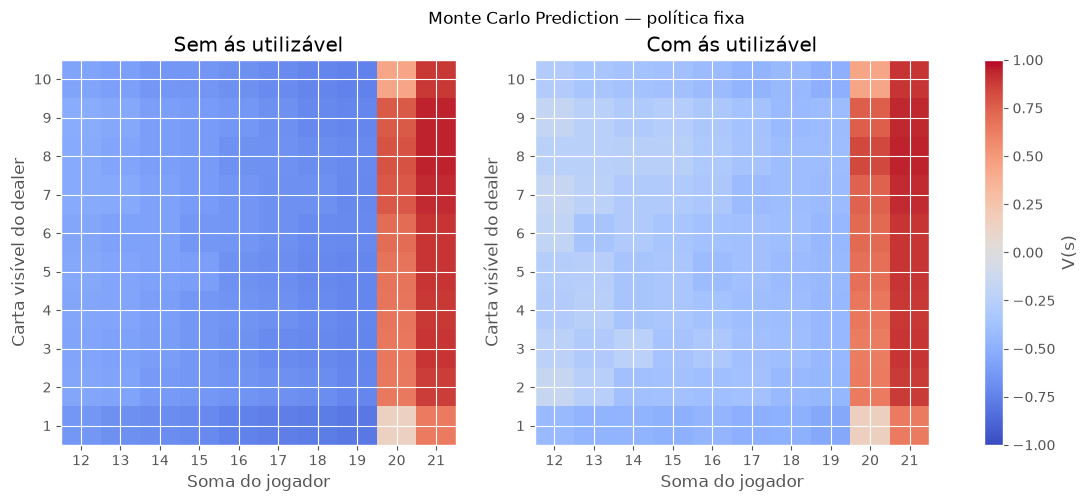

In [30]:
plot_value_heatmaps(
    V_fixed_mean,
    title="Monte Carlo Prediction — política fixa"
)

### 14.2 Função de valor da política aprendida

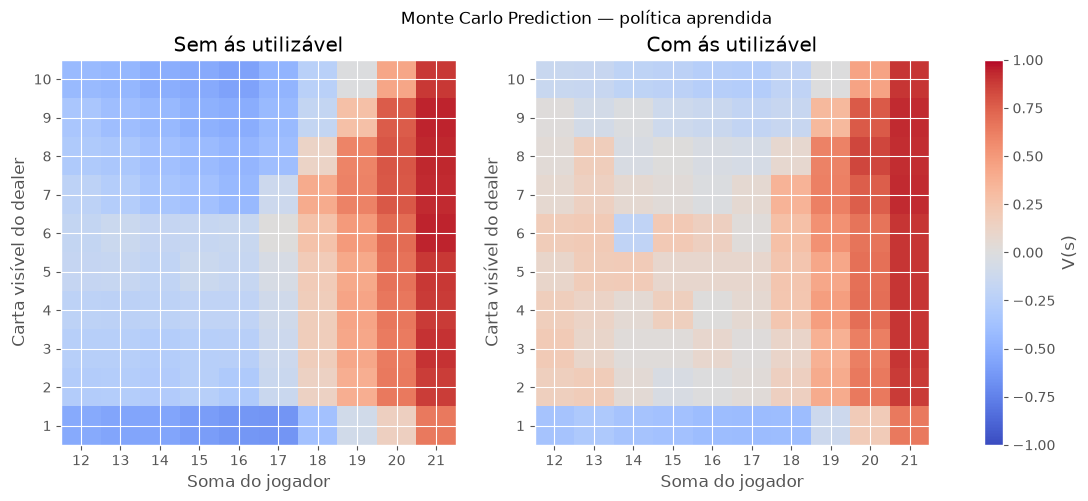

In [31]:
plot_value_heatmaps(
    V_learned_mean,
    title="Monte Carlo Prediction — política aprendida"
)

### 14.3 Ganho de valor produzido pela política aprendida

Para cada estado será calculada a diferença:

$$
\Delta V(s)
=
V^{\pi_{\text{aprendida}}}(s)
-
V^{\pi_{\text{fixa}}}(s)
$$

A interpretação é:

- $\Delta V(s) > 0$: a política aprendida apresenta maior retorno esperado;
- $\Delta V(s) < 0$: a política fixa apresenta maior retorno estimado;
- $\Delta V(s) \approx 0$: as políticas apresentam desempenho semelhante naquele estado.

In [32]:
all_comparison_states = (
    set(V_fixed_mean.keys())
    | set(V_learned_mean.keys())
)

delta_V = defaultdict(float)

for state in all_comparison_states:

    if (
        state in V_fixed_mean
        and state in V_learned_mean
    ):
        delta_V[state] = (
            V_learned_mean[state]
            - V_fixed_mean[state]
        )

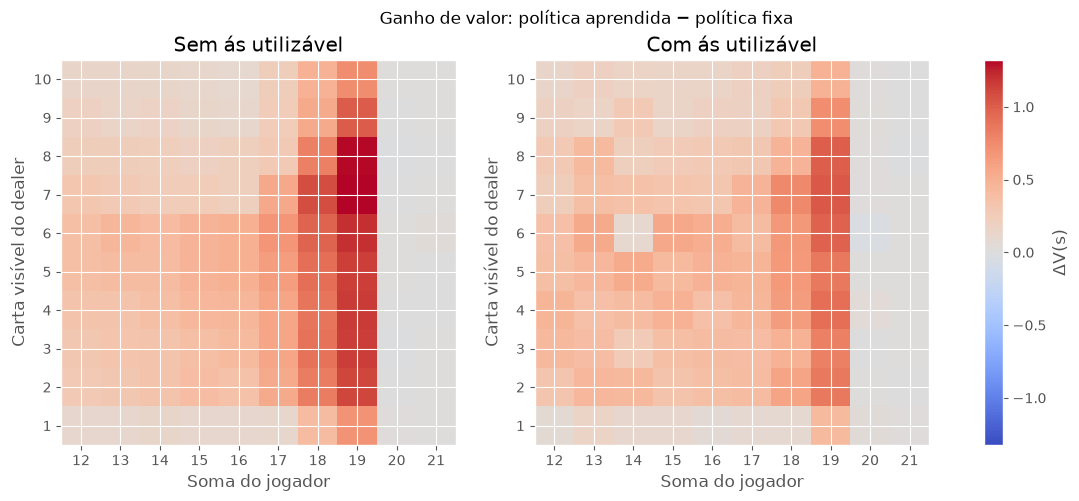

In [33]:
def plot_delta_value_heatmaps(delta_V, title):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    matrices = [
        value_matrix(delta_V, False),
        value_matrix(delta_V, True),
    ]

    max_abs = max(
        np.nanmax(
            np.abs(matrix)
        )
        for matrix in matrices
    )

    for ax, matrix, subtitle in zip(
        axes,
        matrices,
        [
            "Sem ás utilizável",
            "Com ás utilizável"
        ]
    ):

        image = ax.imshow(
            matrix,
            origin="lower",
            aspect="auto",
            vmin=-max_abs,
            vmax=max_abs,
            cmap="coolwarm"
        )

        ax.set_xticks(
            np.arange(len(PLAYER_SUMS))
        )
        ax.set_xticklabels(
            PLAYER_SUMS
        )

        ax.set_yticks(
            np.arange(len(DEALER_CARDS))
        )
        ax.set_yticklabels(
            DEALER_CARDS
        )

        ax.set_xlabel(
            "Soma do jogador"
        )
        ax.set_ylabel(
            "Carta visível do dealer"
        )
        ax.set_title(
            subtitle
        )

    fig.suptitle(title)

    fig.colorbar(
        image,
        ax=axes.ravel().tolist(),
        label="ΔV(s)"
    )

    plt.show()


plot_delta_value_heatmaps(
    delta_V,
    title=(
        "Ganho de valor: "
        "política aprendida − política fixa"
    )
)

### 14.4 Resumo das diferenças de valor

Além da análise visual, serão contabilizados os estados em que a política aprendida apresenta valor maior, menor ou aproximadamente igual ao da política fixa.

In [34]:
delta_values = np.asarray(
    list(delta_V.values())
)

TOLERANCE = 0.01

comparison_summary = pd.DataFrame([
    {
        "Estados comparados": len(delta_values),

        "Aprendida melhor": np.sum(
            delta_values > TOLERANCE
        ),

        "Valores semelhantes": np.sum(
            np.abs(delta_values) <= TOLERANCE
        ),

        "Fixa melhor": np.sum(
            delta_values < -TOLERANCE
        ),

        "Delta V médio": np.mean(
            delta_values
        ),

        "Delta V mediano": np.median(
            delta_values
        ),
    }
])

comparison_summary

,Estados comparados,Aprendida melhor,Valores semelhantes,Fixa melhor,Delta V médio,Delta V mediano
0,280,248,27,5,0.349594,0.333181


### 14.5 Desempenho global das duas políticas

As funções de valor mostram o desempenho condicionado a cada estado.

Como complemento, as duas políticas são executadas a partir da distribuição inicial normal do Blackjack para comparar recompensa média, vitórias, empates e derrotas.

In [35]:
def evaluate_deterministic_policy(
    policy,
    episodes=10_000,
    seed=300_000
):
    env = make_env()

    env.reset(seed=seed)

    rewards = []

    for _ in range(episodes):

        state, info = env.reset()

        terminated = False
        truncated = False

        while not (
            terminated or truncated
        ):

            action = policy(state)

            state, reward, terminated, truncated, info = env.step(
                action
            )

        rewards.append(reward)

    env.close()

    rewards = np.asarray(rewards)

    return {
        "Recompensa média": np.mean(rewards),
        "Taxa de vitória": np.mean(rewards == 1),
        "Taxa de empate": np.mean(rewards == 0),
        "Taxa de derrota": np.mean(rewards == -1),
    }


fixed_evaluation = evaluate_deterministic_policy(
    fixed_policy,
    episodes=10_000,
    seed=300_000
)

learned_evaluation = evaluate_deterministic_policy(
    learned_policy,
    episodes=10_000,
    seed=300_000
)


policy_comparison_df = pd.DataFrame([
    {
        "Política": "Fixa",
        **fixed_evaluation
    },
    {
        "Política": "Aprendida",
        **learned_evaluation
    }
])

policy_comparison_df

,Política,Recompensa média,Taxa de vitória,Taxa de empate,Taxa de derrota
0,Fixa,-0.3614,0.2904,0.0578,0.6518
1,Aprendida,-0.0489,0.4290,0.0931,0.4779


## 15. Monte Carlo Approximate Policy Iteration

O Monte Carlo Control utilizado anteriormente atualiza continuamente $Q(s,a)$ enquanto a política $\epsilon$-greedy muda ao longo dos episódios.

Nesta etapa será testada uma abordagem diferente: separar explicitamente as fases de **avaliação** e **melhoria** da política.

O procedimento será:

1. iniciar com a política gulosa aprendida anteriormente;
2. avaliar essa política aproximadamente por Monte Carlo;
3. estimar $Q^\pi(s,a)$;
4. gerar uma nova política gulosa;
5. repetir até que a política deixe de mudar ou seja atingido o número máximo de iterações.

O processo pode ser representado por:

$$
\pi_0
\rightarrow
Q^{\pi_0}
\rightarrow
\pi_1
\rightarrow
Q^{\pi_1}
\rightarrow
\cdots
$$

Como uma política completamente gulosa poderia deixar de experimentar ações alternativas, a avaliação será realizada com uma política $\epsilon$-soft em torno da política-alvo atual.

Portanto, trata-se de uma forma aproximada de **Generalized Policy Iteration**, utilizando Monte Carlo e exploração contínua.

In [37]:
MAX_POLICY_ITERATIONS = 10
POLICY_EVALUATION_EPISODES = 100_000
POLICY_ITERATION_EPSILON = 0.10

### 15.1 Política inicial

A política inicial será a política gulosa obtida anteriormente pelo Monte Carlo Control com:

- 500.000 episódios;
- $\epsilon = 0.1$;
- `seed = 42`.

In [38]:
def greedy_policy_from_Q(Q):
    policy = {}

    for state, action_values in Q.items():
        policy[state] = int(
            np.argmax(action_values)
        )

    return policy


initial_policy = greedy_policy_from_Q(
    representative_result["Q"]
)

print(
    "Estados presentes na política inicial:",
    len(initial_policy)
)

Estados presentes na política inicial: 280


### 15.2 Política ε-soft para avaliação

Durante a avaliação Monte Carlo, a política atual é utilizada como referência, mas mantém-se uma pequena probabilidade de exploração.

Para duas ações, a política de comportamento atribui:

$$
\pi_b(a \mid s) =
\begin{cases}
1-\epsilon+\frac{\epsilon}{2},
& \text{se } a = \pi(s) \\
\frac{\epsilon}{2},
& \text{caso contrário}
\end{cases}
$$

Isso permite continuar visitando ações alternativas e coletando amostras para os diferentes pares estado-ação.

In [39]:
def make_epsilon_soft_policy(
    target_policy,
    epsilon,
    n_actions
):
    def policy_fn(observation):
        state = tuple(observation)

        probabilities = np.ones(
            n_actions,
            dtype=float
        ) * (epsilon / n_actions)

        if state in target_policy:
            best_action = target_policy[state]
        else:
            best_action = 0

        probabilities[best_action] += (
            1.0 - epsilon
        )

        return probabilities

    return policy_fn

### 15.3 Avaliação Monte Carlo dos valores de ação

Para cada política intermediária, são gerados episódios completos utilizando sua versão ε-soft.

A função estima $Q^\pi(s,a)$ por First Visit Monte Carlo.

In [40]:
def mc_evaluate_action_values(
    env,
    target_policy,
    num_episodes,
    epsilon=0.1,
    gamma=1.0,
    seed=42
):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    Q = defaultdict(
        lambda: np.zeros(
            env.action_space.n,
            dtype=float
        )
    )

    visit_counts = defaultdict(int)

    behavior_policy = make_epsilon_soft_policy(
        target_policy,
        epsilon,
        env.action_space.n
    )

    rng = np.random.default_rng(seed)

    for _ in range(num_episodes):

        episode = generate_episode(
            env,
            behavior_policy,
            rng
        )

        visited_state_actions = set()

        for t, (state, action, reward) in enumerate(episode):

            state = tuple(state)
            state_action = (
                state,
                int(action)
            )

            if state_action in visited_state_actions:
                continue

            visited_state_actions.add(
                state_action
            )

            G = 0.0

            for k, (_, _, reward_k) in enumerate(
                episode[t:]
            ):
                G += (
                    gamma ** k
                ) * reward_k

            returns_sum[state_action] += G
            returns_count[state_action] += 1
            visit_counts[state_action] += 1

            Q[state][action] = (
                returns_sum[state_action]
                / returns_count[state_action]
            )

    return Q, visit_counts

### 15.4 Policy Improvement

Após a avaliação, uma nova política gulosa é construída escolhendo, em cada estado:

$$
\pi'(s)
=
\arg\max_a Q^\pi(s,a)
$$

In [41]:
def improve_policy(Q):
    policy = {}

    for state, action_values in Q.items():
        policy[state] = int(
            np.argmax(action_values)
        )

    return policy

### 15.5 Comparação entre políticas sucessivas

A quantidade de estados cuja ação mudou será usada como indicador de estabilidade.

Se nenhuma ação mudar, considera-se que a política convergiu para a precisão amostral do experimento.

In [42]:
def count_policy_changes(
    old_policy,
    new_policy
):
    states = (
        set(old_policy.keys())
        | set(new_policy.keys())
    )

    changes = 0

    for state in states:
        if old_policy.get(state) != new_policy.get(state):
            changes += 1

    return changes

### 15.6 Execução do Monte Carlo Approximate Policy Iteration

A política gulosa aprendida pelo Control será refinada iterativamente.

Cada iteração utiliza uma seed distinta para evitar repetir exatamente a mesma sequência de episódios.

In [43]:
current_policy = initial_policy.copy()

approx_policy_iteration_history = []

for iteration in range(
    1,
    MAX_POLICY_ITERATIONS + 1
):
    env = make_env()

    iteration_seed = (
        BASE_SEED + 1000 + iteration
    )

    env.reset(
        seed=iteration_seed
    )

    Q_evaluated, visit_counts = mc_evaluate_action_values(
        env,
        current_policy,
        num_episodes=POLICY_EVALUATION_EPISODES,
        epsilon=POLICY_ITERATION_EPSILON,
        gamma=GAMMA,
        seed=iteration_seed
    )

    env.close()

    new_policy = improve_policy(
        Q_evaluated
    )

    changes = count_policy_changes(
        current_policy,
        new_policy
    )

    approx_policy_iteration_history.append({
        "iteration": iteration,
        "changes": changes,
        "Q": Q_evaluated,
        "policy": new_policy,
        "visit_counts": visit_counts,
    })

    print(
        f"Iteração {iteration}: "
        f"{changes} estados alterados"
    )

    current_policy = new_policy

    if changes == 0:
        print(
            "Política estabilizada."
        )
        break

Iteração 1: 41 estados alterados
Iteração 2: 71 estados alterados
Iteração 3: 74 estados alterados
Iteração 4: 63 estados alterados
Iteração 5: 68 estados alterados
Iteração 6: 60 estados alterados
Iteração 7: 65 estados alterados
Iteração 8: 68 estados alterados
Iteração 9: 74 estados alterados
Iteração 10: 77 estados alterados


### 15.7 Evolução das mudanças da política

O gráfico mostra quantos estados tiveram sua ação alterada após cada etapa de avaliação e melhoria.

Espera-se que esse número diminua à medida que a política se aproxima de uma configuração estável.

Como a avaliação é baseada em amostragem Monte Carlo, pequenas oscilações podem ocorrer entre iterações.

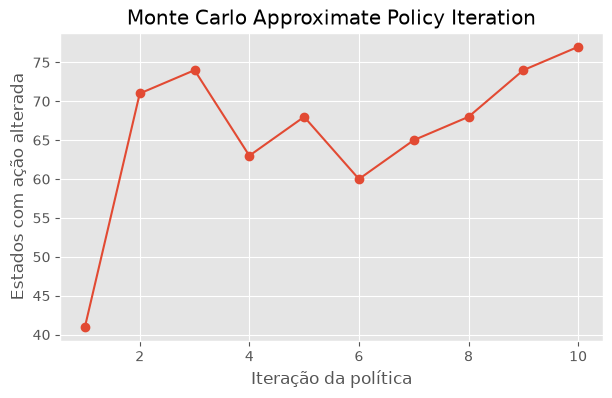

In [44]:
iterations = [
    result["iteration"]
    for result in approx_policy_iteration_history
]

changes = [
    result["changes"]
    for result in approx_policy_iteration_history
]

plt.figure(figsize=(7, 4))

plt.plot(
    iterations,
    changes,
    marker="o"
)

plt.xlabel(
    "Iteração da política"
)

plt.ylabel(
    "Estados com ação alterada"
)

plt.title(
    "Monte Carlo Approximate Policy Iteration"
)

plt.grid(True)

plt.show()

## 16. Avaliação da política refinada

A política final obtida pelo processo iterativo será comparada com:

- a política fixa original;
- a política aprendida diretamente pelo Monte Carlo Control;
- a política refinada pelo Monte Carlo Approximate Policy Iteration.

Todas serão avaliadas de forma gulosa, sem exploração ε-greedy.

In [45]:
refined_policy = current_policy


def refined_policy_fn(observation):
    state = tuple(observation)

    if state in refined_policy:
        return refined_policy[state]

    return 0

In [46]:
fixed_evaluation = evaluate_deterministic_policy(
    fixed_policy,
    episodes=10_000,
    seed=400_000
)

learned_evaluation = evaluate_deterministic_policy(
    learned_policy,
    episodes=10_000,
    seed=400_000
)

refined_evaluation = evaluate_deterministic_policy(
    refined_policy_fn,
    episodes=10_000,
    seed=400_000
)


refined_comparison_df = pd.DataFrame([
    {
        "Política": "Fixa",
        **fixed_evaluation
    },
    {
        "Política": "MC Control",
        **learned_evaluation
    },
    {
        "Política": "MC Policy Iteration",
        **refined_evaluation
    }
])

refined_comparison_df

,Política,Recompensa média,Taxa de vitória,Taxa de empate,Taxa de derrota
0,Fixa,-0.3478,0.2953,0.0616,0.6431
1,MC Control,-0.0618,0.4263,0.0856,0.4881
2,MC Policy Iteration,-0.0791,0.4182,0.0845,0.4973


### 16.1 Interpretação

Esta comparação permite verificar se a separação explícita entre avaliação e melhoria de política produz ganhos adicionais em relação ao Monte Carlo Control tradicional.

Três resultados são possíveis:

1. **melhora significativa**  
   A política refinada apresenta recompensa média maior que a política obtida diretamente pelo Control;

2. **resultado semelhante**  
   As políticas apresentam desempenho muito próximo, sugerindo que o Monte Carlo Control já havia encontrado uma política próxima da solução estável;

3. **pequena degradação ou oscilação**  
   Como a avaliação de $Q(s,a)$ é amostral, mudanças pequenas podem decorrer da variabilidade Monte Carlo e não representar melhora real da política.

### 16.2 Visualização da política refinada

O mapa abaixo mostra a política final obtida pelo Monte Carlo Approximate Policy Iteration, separando os estados sem ás utilizável e com ás utilizável.

A visualização permite comparar qualitativamente essa política com a política obtida anteriormente pelo Monte Carlo Control.

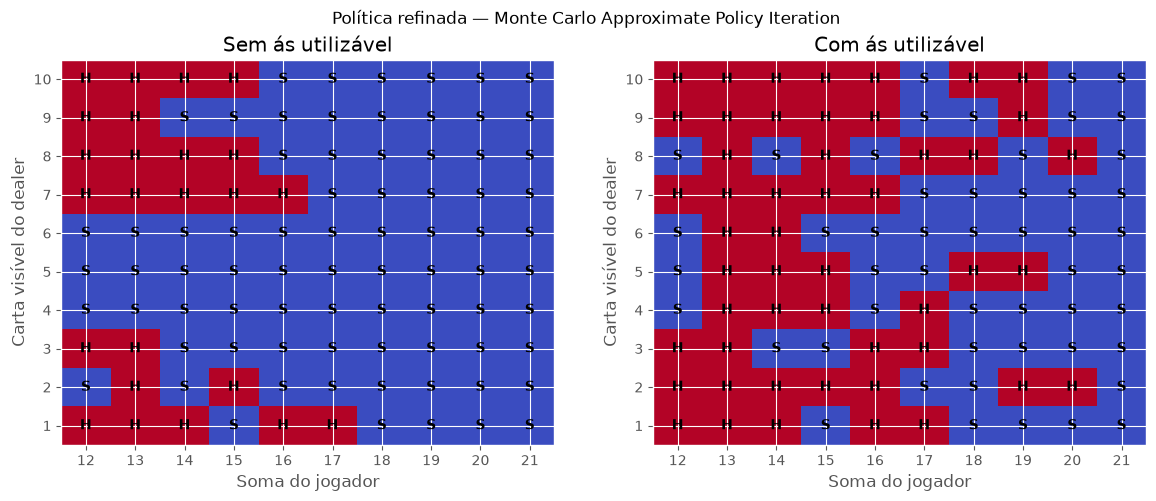

In [48]:
final_iteration_result = (
    approx_policy_iteration_history[-1]
)

plot_policy(
    final_iteration_result["Q"],
    title=(
        "Política refinada — "
        "Monte Carlo Approximate Policy Iteration"
    )
)

### 16.3 Interpretação do mapa da política refinada

O mapa da política refinada confirma visualmente a instabilidade observada no gráfico de mudanças por iteração.

Em comparação com a política aprendida diretamente pelo Monte Carlo Control, a política refinada apresenta um padrão mais fragmentado, com alternâncias locais entre `hit` e `stick` em estados vizinhos, especialmente na região com ás utilizável.

Uma política estável tende a apresentar fronteiras de decisão mais suaves e coerentes. Neste caso, a presença de várias “ilhas” de decisão sugere que pequenas flutuações amostrais nas estimativas de $Q(s,a)$ provocaram mudanças frequentes na política.

Essa evidência qualitativa é consistente com o resultado quantitativo: o número de estados com ação alterada permaneceu elevado ao longo das iterações e a política final apresentou recompensa média inferior àquela obtida diretamente pelo Monte Carlo Control.

## 17. Pontos para discussão

Os resultados obtidos permitem discutir diferentes aspectos do comportamento do Monte Carlo Control e das extensões realizadas no experimento:

1. **Quantidade de episódios**  
   O aumento do número de episódios melhorou progressivamente o desempenho da política aprendida. Com mais amostras, as estimativas de $Q(s,a)$ tornam-se mais estáveis e a política resultante tende a apresentar maior recompensa média, maior taxa de vitória e menor taxa de derrota.

2. **Exploração e valor de $\epsilon$**  
   O parâmetro $\epsilon$ controla o equilíbrio entre exploração e aproveitamento. Valores muito baixos limitaram a exploração do espaço estado-ação e produziram desempenho inferior. No intervalo testado, valores maiores de $\epsilon$ aumentaram a cobertura e melhoraram o resultado final, embora os experimentos não permitam concluir que aumentos sucessivos de $\epsilon$ continuariam produzindo ganhos.

3. **Cobertura do espaço estado-ação**  
   O aumento de $\epsilon$ ampliou a quantidade de pares $(s,a)$ efetivamente visitados até que a cobertura atingisse 560 pares. A partir de $\epsilon=0.10$, aumentar $\epsilon$ para 0.20 não aumentou a cobertura, indicando saturação. Assim, diferenças de desempenho posteriores não podem ser explicadas apenas pela descoberta de novos pares estado-ação, mas também pela distribuição e frequência das visitas entre pares já conhecidos.

4. **Quantidade de episódios após a saturação da cobertura**  
   Com 100.000 episódios, todos os 560 pares observáveis já haviam sido visitados para $\epsilon=0.10$. O aumento para 500.000 episódios continuou melhorando o desempenho mesmo sem ampliar a cobertura. Isso indica que o ganho adicional decorreu principalmente do aumento da quantidade de amostras utilizadas na estimação de $Q(s,a)$, reduzindo a incerteza associada aos valores de ação.

5. **Política de comportamento × política avaliada**  
   Durante o treinamento, o agente utiliza uma política $\epsilon$-greedy para garantir exploração. Entretanto, a avaliação final utiliza a política gulosa derivada de $Q(s,a)$, sem exploração adicional. Essa separação permite avaliar a qualidade da política efetivamente aprendida sem incorporar à métrica final a aleatoriedade necessária durante o treinamento.

6. **Monte Carlo e episódios completos**  
   As atualizações de Monte Carlo dependem do retorno completo $G_t$, que somente pode ser calculado após o término do episódio. Diferentemente dos métodos de diferenças temporais, não ocorre bootstrapping a partir de estimativas de estados seguintes. Essa característica torna o método conceitualmente simples, mas pode exigir grande quantidade de episódios para produzir estimativas estáveis.

7. **Comparação entre a política fixa e a política aprendida**  
   A aplicação de Monte Carlo Prediction à política aprendida permitiu comparar diretamente $V^{\pi_{\text{fixa}}}(s)$ e $V^{\pi_{\text{aprendida}}}(s)$. A política aprendida apresentou maior valor em 248 dos 280 estados comparados, com ganho médio de aproximadamente 0,35 em $V(s)$. A avaliação global também mostrou aumento da taxa de vitória e redução expressiva da taxa de derrota, confirmando que o Monte Carlo Control produziu uma política significativamente superior à política fixa utilizada inicialmente.

8. **Recompensa média ainda negativa**  
   Mesmo após o aprendizado, a recompensa média permaneceu negativa. Isso não significa falha do algoritmo. O Monte Carlo Control busca maximizar o retorno esperado dentro das regras do ambiente, mas não pode eliminar uma eventual vantagem estrutural do dealer. O resultado importante é a melhora relativa obtida em relação à política fixa.

9. **Prediction após o Control**  
   Utilizar novamente Monte Carlo Prediction após o processo de Control mostrou-se útil para interpretar a política aprendida estado a estado. Enquanto o Control responde quais ações devem ser escolhidas, o Prediction posterior mostra qual retorno pode ser esperado ao seguir essas decisões a partir de cada estado.

10. **Tentativa de Monte Carlo Approximate Policy Iteration**  
    Foi testado um processo adicional de refinamento no qual a política aprendida pelo Control foi utilizada como ponto inicial para ciclos explícitos de avaliação Monte Carlo e melhoria da política. Diferentemente da Policy Iteration baseada em Programação Dinâmica, esse procedimento não apresentou convergência: o número de estados com ações alteradas permaneceu elevado e oscilante entre as iterações.

11. **Instabilidade do refinamento iterativo**  
    A instabilidade observada pode ser explicada pela natureza amostral da avaliação Monte Carlo. Pequenas diferenças nas estimativas de $Q(s,a)$ podem alterar o resultado de $\arg\max_a Q(s,a)$ e provocar mudanças simultâneas em muitos estados. Além disso, a avaliação foi realizada por uma política $\epsilon$-soft, enquanto a etapa de melhoria produzia uma política gulosa, de modo que a política avaliada não era exatamente a mesma política posteriormente melhorada.

12. **Resultado do Monte Carlo Approximate Policy Iteration**  
    O refinamento iterativo não melhorou a solução inicial. A política obtida diretamente pelo Monte Carlo Control apresentou recompensa média superior à política resultante do Approximate Policy Iteration. Dessa forma, a hipótese de que alternar explicitamente avaliação e melhoria produziria ganho adicional não foi confirmada neste experimento.

13. **Análise qualitativa das políticas**  
    O mapa da política produzida diretamente pelo Monte Carlo Control apresentou regiões de decisão relativamente coerentes entre `hit` e `stick`. Já a política refinada apresentou maior fragmentação, com várias alternâncias locais entre ações em estados vizinhos, especialmente nos estados com ás utilizável. Essa irregularidade visual é consistente com a ausência de convergência observada quantitativamente.

14. **Limitações experimentais**  
    Os resultados dependem do número de episódios, das seeds utilizadas, do valor de $\epsilon$ e da configuração específica do `Blackjack-v1`. Como as estimativas Monte Carlo são amostrais, pequenas diferenças de desempenho entre configurações devem ser interpretadas considerando sua variabilidade. Uma análise mais rigorosa poderia utilizar maior número de repetições, intervalos de confiança e outras estratégias de exploração ou avaliação off-policy.

## 18. Correspondência com o relatório

| Seção do relatório | Evidência produzida neste notebook |
|---|---|
| **1. Introdução** | Objetivo do experimento com Monte Carlo Control, hipóteses sobre número de episódios, exploração e possibilidade de melhoria da política. |
| **2. Fundamentação Teórica** | Monte Carlo Control First Visit, função de valor de ação $Q(s,a)$, política $\epsilon$-greedy, relação entre exploração e aproveitamento, Monte Carlo Prediction e tentativa de Approximate Policy Iteration. |
| **2.2. Ambiente** | Descrição do `Blackjack-v1`, representação do estado, ações `hit` e `stick`, regras de recompensa, término dos episódios e configuração `natural=False` e `sab=False`. |
| **3. Metodologia Experimental** | Uso de múltiplas seeds, diferentes números de episódios, diferentes valores de $\epsilon$, política de comportamento $\epsilon$-greedy, avaliação gulosa e separação entre treinamento e avaliação. |
| **3.2. Treinamento e Avaliação** | Aprendizado de $Q(s,a)$ por Monte Carlo Control, geração de episódios completos, avaliação da política gulosa, análise de cobertura dos pares $(s,a)$ e execução posterior de Monte Carlo Prediction sobre a política aprendida. |
| **4. Resultados** | Tabelas de recompensa média, desvio padrão, taxas de vitória, empate e derrota, passos médios, cobertura estado-ação, gráficos do efeito do número de episódios e de $\epsilon$, mapas da política aprendida, heatmaps de $V(s)$ e de $\Delta V(s)$. |
| **4. Resultados — comparação de políticas** | Comparação entre política fixa e política aprendida, incluindo ganho médio de valor por estado, número de estados em que cada política foi superior e comparação global de desempenho. |
| **4. Resultados — refinamento iterativo** | Evolução do número de estados alterados no Monte Carlo Approximate Policy Iteration, mapa da política refinada e comparação de desempenho entre política fixa, MC Control e política refinada. |
| **5. Discussão** | Efeito da quantidade de episódios, impacto de $\epsilon$, saturação da cobertura, diferença entre cobertura e frequência de amostragem, política de comportamento versus política avaliada, limitações do Monte Carlo e análise da instabilidade do refinamento iterativo. |
| **6. Conclusões** | Evidências de que maior amostragem melhora as estimativas de $Q(s,a)$, exploração insuficiente prejudica o aprendizado, o MC Control supera claramente a política fixa e o refinamento por Approximate Policy Iteration não apresentou ganho adicional neste experimento. |